In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

df = pd.read_csv("combined_financial_dataset.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (11194, 2)


,text,sentiment
0,"According to Gran , the company has no plans t...",neutral
1,With the new production plant the company woul...,positive
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,"In the third quarter of 2010 , net sales incre...",positive
4,Operating profit rose to EUR 13.1 mn from EUR ...,positive


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11194 entries, 0 to 11193
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       11194 non-null  object
 1   sentiment  11194 non-null  object
dtypes: object(2)
memory usage: 175.0+ KB


In [3]:
print("\nSentiment Distribution:")
print(df["sentiment"].value_counts())


Sentiment Distribution:
sentiment
unlabeled    7746
neutral      2141
positive      887
negative      420
Name: count, dtype: int64


In [4]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
text         0
sentiment    0
dtype: int64


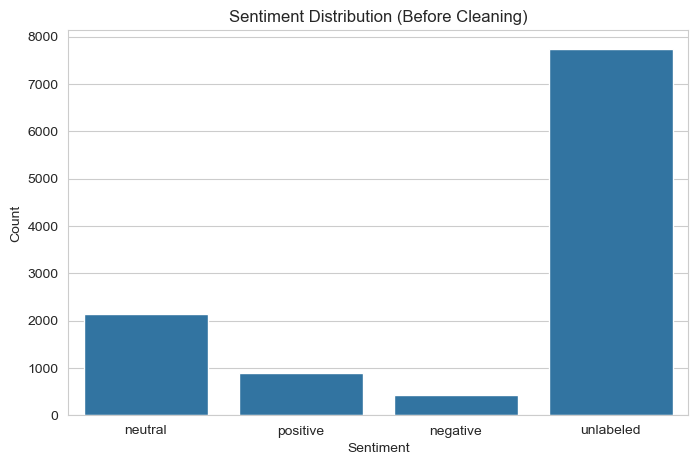

In [5]:
plt.figure()
sns.countplot(data=df, x="sentiment")
plt.title("Sentiment Distribution (Before Cleaning)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

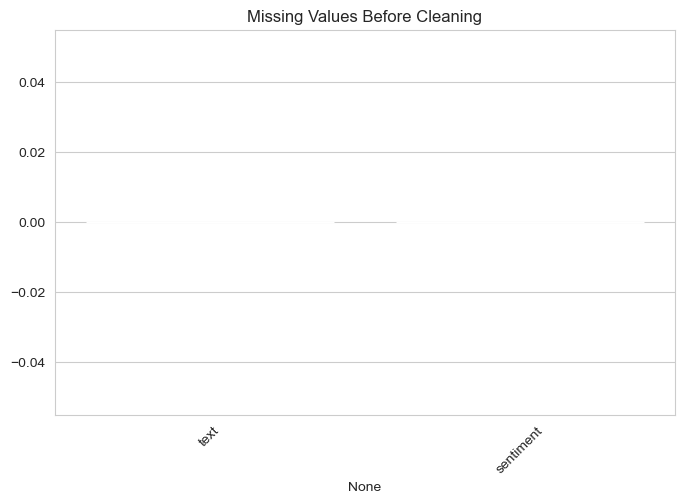

In [6]:
missing_counts = df.isnull().sum()

plt.figure()
sns.barplot(x=missing_counts.index, y=missing_counts.values)
plt.title("Missing Values Before Cleaning")
plt.xticks(rotation=45)
plt.show()

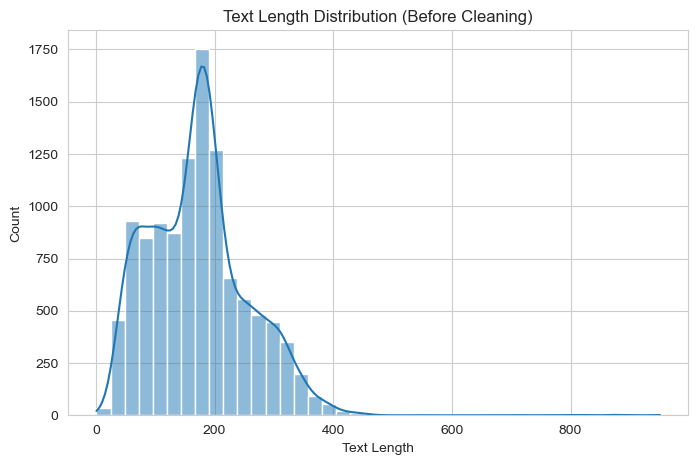

In [7]:
df["text_length"] = df["text"].astype(str).apply(len)

plt.figure()
sns.histplot(df["text_length"], bins=40, kde=True)
plt.title("Text Length Distribution (Before Cleaning)")
plt.xlabel("Text Length")
plt.show()

In [8]:
# Drop rows where text is missing
df = df.dropna(subset=["text"])

# Remove empty strings
df = df[df["text"].str.strip() != ""]

print("After Removing Missing/Empty Text:", df.shape)

After Removing Missing/Empty Text: (11193, 3)


In [9]:
labeled_df = df[df["sentiment"] != "unlabeled"].copy()

print("Training Dataset Shape:", labeled_df.shape)
print(labeled_df["sentiment"].value_counts())

Training Dataset Shape: (3448, 3)
sentiment
neutral     2141
positive     887
negative     420
Name: count, dtype: int64


In [10]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Lowercase
    text = text.lower()
    
    # Remove special characters (keep numbers and %)
    text = re.sub(r"[^a-z0-9%\s]", "", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    # Tokenization
    words = text.split()
    
    # Remove stopwords (but keep financial negations like 'not')
    words = [word for word in words if word not in stop_words or word in ["not", "no"]]
    
    # Lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]
    
    return " ".join(words)

labeled_df["cleaned_text"] = labeled_df["text"].apply(clean_text)

labeled_df.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/aayushbohara/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/aayushbohara/nltk_data...


,text,sentiment,text_length,cleaned_text
0,"According to Gran , the company has no plans t...",neutral,127,according gran company no plan move production...
1,With the new production plant the company woul...,positive,206,new production plant company would increase ca...
2,"For the last quarter of 2010 , Componenta 's n...",positive,193,last quarter 2010 componenta net sale doubled ...
3,"In the third quarter of 2010 , net sales incre...",positive,125,third quarter 2010 net sale increased 52 % eur...
4,Operating profit rose to EUR 13.1 mn from EUR ...,positive,122,operating profit rose eur 131 mn eur 87 mn cor...


In [11]:
labeled_df = labeled_df.drop_duplicates(subset="cleaned_text")

print("After Removing Duplicates:", labeled_df.shape)

After Removing Duplicates: (3440, 4)


In [12]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
labeled_df["sentiment_encoded"] = label_encoder.fit_transform(labeled_df["sentiment"])

print("Label Mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label} -> {i}")

Label Mapping:
negative -> 0
neutral -> 1
positive -> 2


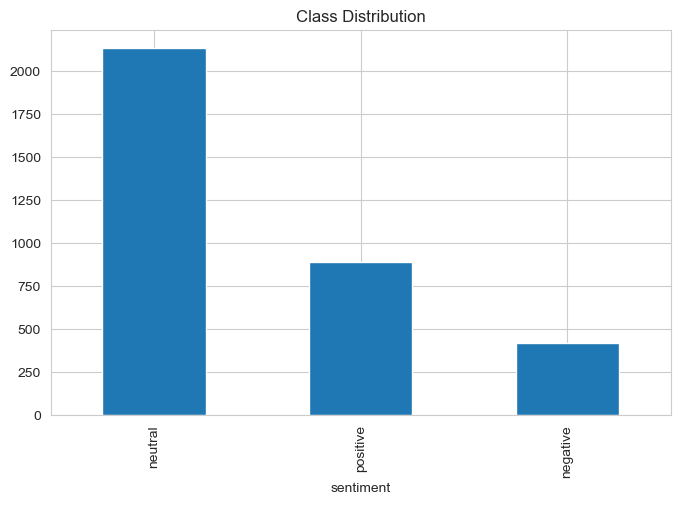

In [13]:
import matplotlib.pyplot as plt

labeled_df["sentiment"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.show()

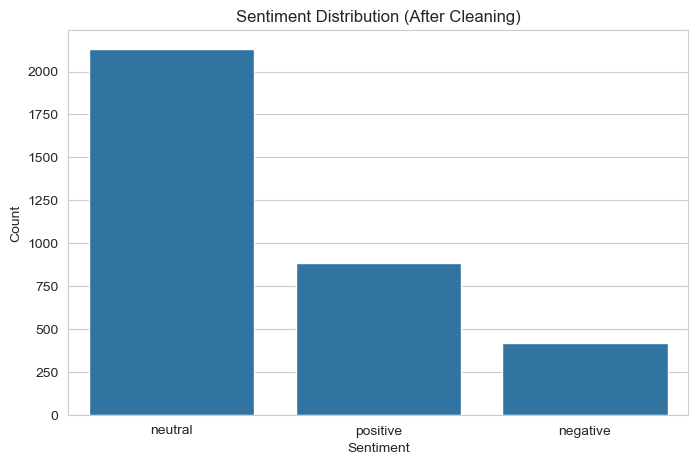

In [14]:
plt.figure()
sns.countplot(data=labeled_df, x="sentiment")
plt.title("Sentiment Distribution (After Cleaning)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

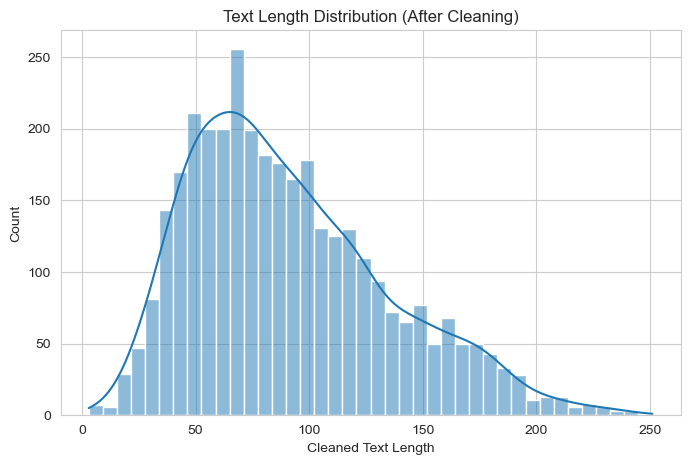

In [15]:
labeled_df["cleaned_length"] = labeled_df["cleaned_text"].apply(len)

plt.figure()
sns.histplot(labeled_df["cleaned_length"], bins=40, kde=True)
plt.title("Text Length Distribution (After Cleaning)")
plt.xlabel("Cleaned Text Length")
plt.show()

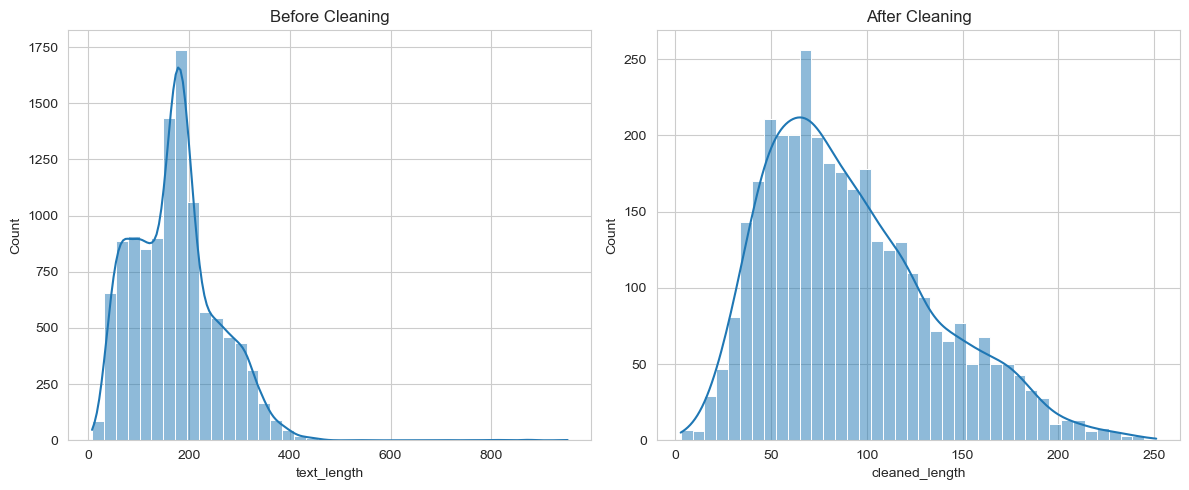

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.histplot(df["text_length"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Before Cleaning")

sns.histplot(labeled_df["cleaned_length"], bins=40, kde=True, ax=axes[1])
axes[1].set_title("After Cleaning")

plt.tight_layout()
plt.show()

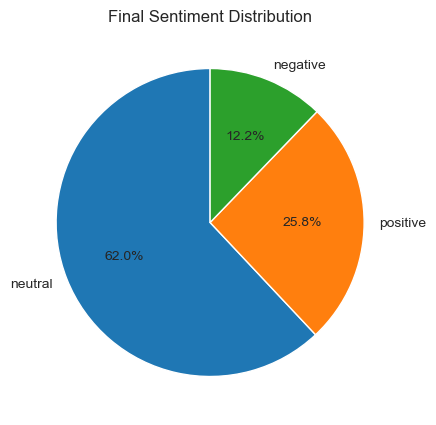

In [17]:
plt.figure()
labeled_df["sentiment"].value_counts().plot.pie(
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Final Sentiment Distribution")
plt.ylabel("")
plt.show()

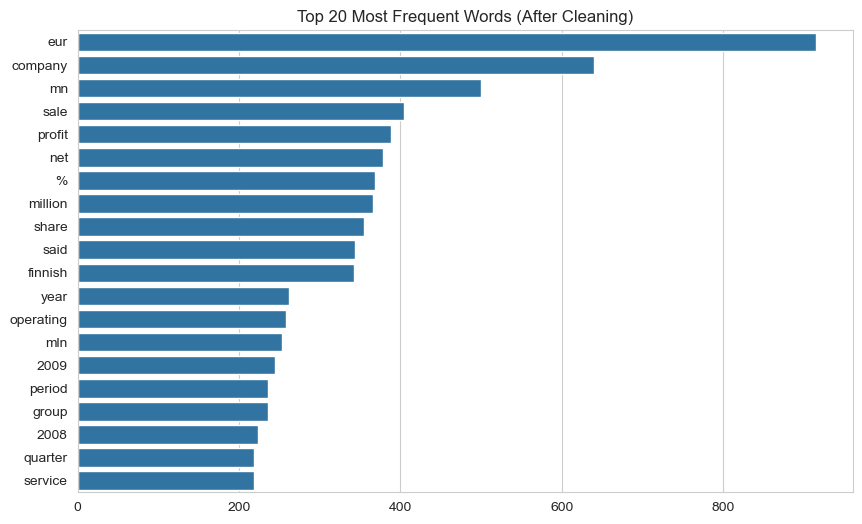

In [18]:
from collections import Counter

all_words = " ".join(labeled_df["cleaned_text"]).split()
word_freq = Counter(all_words)
common_words = word_freq.most_common(20)

words, counts = zip(*common_words)

plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words))
plt.title("Top 20 Most Frequent Words (After Cleaning)")
plt.show()

In [19]:
labeled_df.to_csv("cleaned_financial_dataset.csv", index=False)

print("Cleaned dataset saved as cleaned_financial_dataset.csv")

Cleaned dataset saved as cleaned_financial_dataset.csv
